# XGBoost Forecasting – Waste by Canteen Section

This notebook builds separate XGBoost models for sections **A, B, C, D**.
For each section

In [14]:
import os
import pickle
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

os.makedirs("models/xgboost", exist_ok=True)

## 1. Load and Prepare Data

The dataset `waste_features_xgb.csv` contains engineered features: lag values, rolling statistics, cyclical date encodings, and section dummies — ready for tree‑based models.

In [15]:
df = pd.read_csv("data/waste_features_xgb.csv")
print(f"Full dataset shape: {df.shape}")
print(df.head())

Full dataset shape: (612, 32)
   waste_kg  waste_organic_kg  waste_recyclable_kg  waste_landfill_kg  \
0      7.85              4.13                 2.22               1.47   
1     11.83              5.99                 3.87               1.96   
2     12.18              6.75                 3.77               1.63   
3      9.62              5.07                 3.03               1.50   
4      7.18              3.92                 2.31               0.94   

   foot_traffic  is_holiday  has_special_event  year  month  day  ...  lag_28  \
0     36.666667           0                  1  2025      1   29  ...    7.59   
1     47.923077           0                  1  2025      1   30  ...    3.38   
2     37.687500           1                  1  2025      1   31  ...    7.73   
3     27.714286           0                  1  2025      2    1  ...   13.92   
4     32.142857           0                  1  2025      2    2  ...    2.73   

   rolling_mean_7  rolling_mean_14  rolling_

## 2. Helper Functions

- `prepare_section_data()`: filter section, drop section‑identity columns, split into train/test (last 30 rows as test).
- `cross_validate_params()`: walk‑forward grid search over XGBoost hyperparameters.
- `train_and_evaluate()`: train an XGBoost regressor (baseline or tuned) and evaluate on test set.
- `plot_forecast()`: visualise actual vs forecast.

In [16]:
# Columns that identify the section — drop before training
SECTION_COLS = ["section_encoded", "section_a", "section_b", "section_c", "section_d"]
TARGET       = "waste_kg"

# Map section letter → boolean column name in the CSV
SECTION_FLAG = {"a": "section_a", "b": "section_b", "c": "section_c", "d": "section_d"}


def prepare_section_data(df, section, test_rows=30):
    """Filter rows for one section, drop section identity columns, split train/test."""
    flag_col = SECTION_FLAG[section]
    sec_df = df[df[flag_col] == True].copy()
    sec_df = sec_df.drop(columns=SECTION_COLS, errors="ignore")
    sec_df = sec_df.reset_index(drop=True)

    train = sec_df.iloc[:-test_rows]
    test  = sec_df.iloc[-test_rows:]
    return sec_df, train, test


def get_X_y(data):
    """Split a DataFrame into feature matrix X and target vector y."""
    X = data.drop(columns=[TARGET])
    y = data[TARGET]
    return X, y


def cross_validate_params(train, param_grid, n_splits=3):
    """
    Walk‑forward cross‑validation grid search for XGBoost hyperparameters.
    Returns the best params dict by mean RMSE across folds.
    """
    all_params = [
        dict(zip(param_grid.keys(), v))
        for v in itertools.product(*param_grid.values())
    ]

    n = len(train)
    fold_size = n // (n_splits + 1)

    results = []
    for params in all_params:
        fold_rmses = []
        for k in range(1, n_splits + 1):
            train_fold = train.iloc[: k * fold_size]
            val_fold   = train.iloc[k * fold_size : (k + 1) * fold_size]
            if len(val_fold) == 0:
                continue
            X_tr, y_tr = get_X_y(train_fold)
            X_val, y_val = get_X_y(val_fold)
            model = xgb.XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                verbosity=0,
                **params
            )
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            fold_rmses.append(rmse)
        results.append({**params, "cv_rmse": np.mean(fold_rmses)})

    best = min(results, key=lambda x: x["cv_rmse"])
    best.pop("cv_rmse")
    return best


def train_and_evaluate(train, test, params=None):
    """Train an XGBoost model (baseline if params=None, else tuned) and evaluate on test."""
    X_train, y_train = get_X_y(train)
    X_test,  y_test  = get_X_y(test)

    if params is None:
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            verbosity=0
        )
    else:
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            verbosity=0,
            **params
        )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
    return model, {"rmse": rmse, "mae": mae, "mape": mape}, y_pred


def plot_forecast(test, y_pred, title, ax):
    """Plot actual vs forecast."""
    ax.plot(range(len(test)), test[TARGET].values, label="Actual",
            marker="o", markersize=3, color="black")
    ax.plot(range(len(test)), y_pred, label="Forecast",
            linestyle="--", color="blue")
    ax.set_title(title)
    ax.set_xlabel("Day (test period)")
    ax.set_ylabel("Waste (kg)")
    ax.legend()


print("Helper functions defined.")

Helper functions defined.


## 3. Train & Tune Models for All Sections (A, B, C, D)

For each section:
- Split data (last 30 rows = test set)
- Find best hyperparameters via walk‑forward cross‑validation (grid search)
- Train baseline (default XGBoost) and tuned models, evaluate on test
- Save tuned model as pickle
- Store metrics for comparison


Processing Section A
Train size: 123, Test size: 30
Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Saved tuned model to models/xgboost/xgboost_section_a.pkl


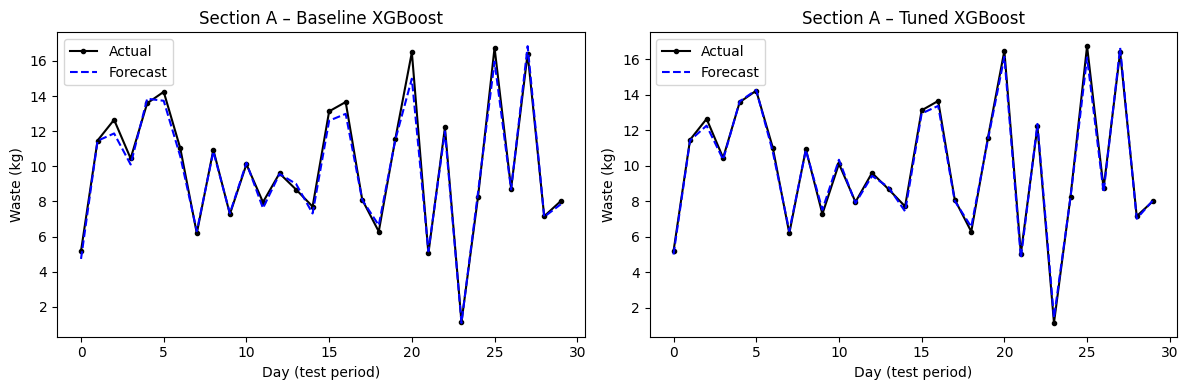


Processing Section B
Train size: 123, Test size: 30
Best params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Saved tuned model to models/xgboost/xgboost_section_b.pkl


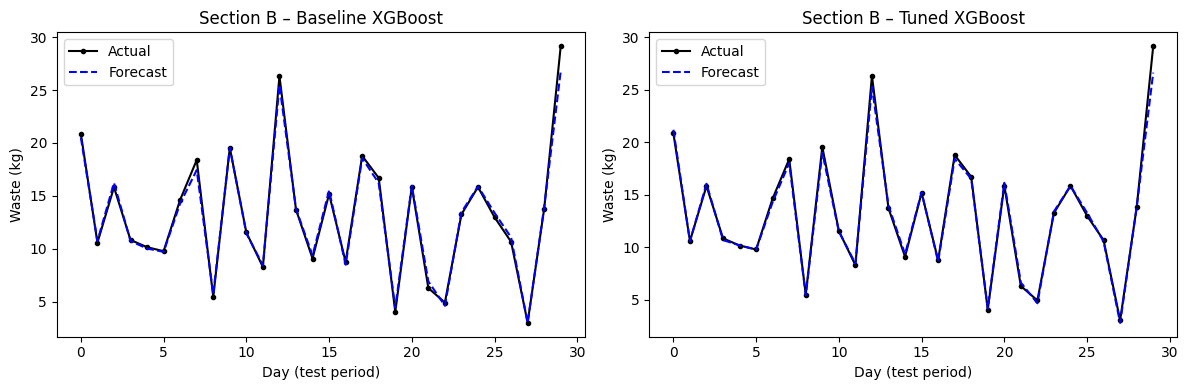


Processing Section C
Train size: 123, Test size: 30
Best params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Saved tuned model to models/xgboost/xgboost_section_c.pkl


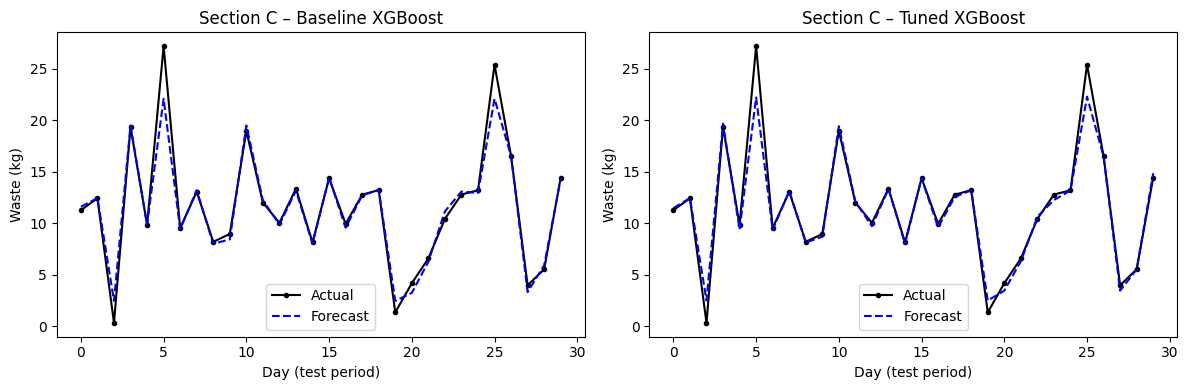


Processing Section D
Train size: 123, Test size: 30
Best params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Saved tuned model to models/xgboost/xgboost_section_d.pkl


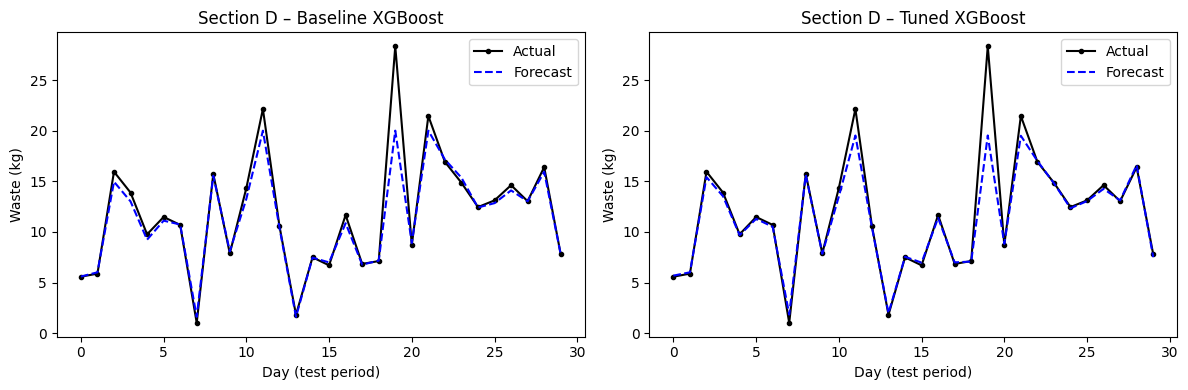


All sections processed.


In [17]:
# Hyperparameter grid
param_grid = {
    "n_estimators":    [100, 300],
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.05, 0.1, 0.2],
    "subsample":       [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

sections = ["a", "b", "c", "d"]
results  = []

for section in sections:
    print(f"\n{'='*50}")
    print(f"Processing Section {section.upper()}")
    print('='*50)

    # Prepare data
    _, train, test = prepare_section_data(df, section, test_rows=30)
    print(f"Train size: {len(train)}, Test size: {len(test)}")

    # Cross‑validation tuning
    best_params = cross_validate_params(train, param_grid, n_splits=3)
    print(f"Best params: {best_params}")

    # Baseline model (default XGBoost)
    baseline_model, baseline_metrics, baseline_pred = train_and_evaluate(train, test, params=None)

    # Tuned model
    tuned_model, tuned_metrics, tuned_pred = train_and_evaluate(train, test, params=best_params)

    # Save tuned model
    model_path = f"models/xgboost/xgboost_section_{section}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(tuned_model, f)
    print(f"Saved tuned model to {model_path}")

    # Store metrics
    results.append({
        "section":        section.upper(),
        "baseline_rmse":  baseline_metrics["rmse"],
        "tuned_rmse":     tuned_metrics["rmse"],
        "baseline_mae":   baseline_metrics["mae"],
        "tuned_mae":      tuned_metrics["mae"],
        "baseline_mape":  baseline_metrics["mape"],
        "tuned_mape":     tuned_metrics["mape"]
    })

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_forecast(test, baseline_pred, f"Section {section.upper()} – Baseline XGBoost", axes[0])
    plot_forecast(test, tuned_pred,    f"Section {section.upper()} – Tuned XGBoost",    axes[1])
    plt.tight_layout()
    plt.show()

print("\nAll sections processed.")

## 4. Performance Comparison: Baseline vs Tuned

We summarise RMSE, MAE and MAPE for each section and compute the percentage improvement achieved by tuning.


=== Model Performance Summary ===
section  baseline_rmse  tuned_rmse  baseline_mae  tuned_mae  baseline_mape  tuned_mape  rmse_improvement_%  mae_improvement_%
      A       0.445707    0.224310      0.316208   0.183846       3.067652    2.648440               49.67              41.86
      B       0.557023    0.546202      0.348915   0.295120       2.801095    2.167399                1.94              15.42
      C       1.239067    1.193409      0.621240   0.577589      29.171687   28.872147                3.68               7.03
      D       1.649279    1.739233      0.690235   0.638633       6.012002    6.132127               -5.45               7.48


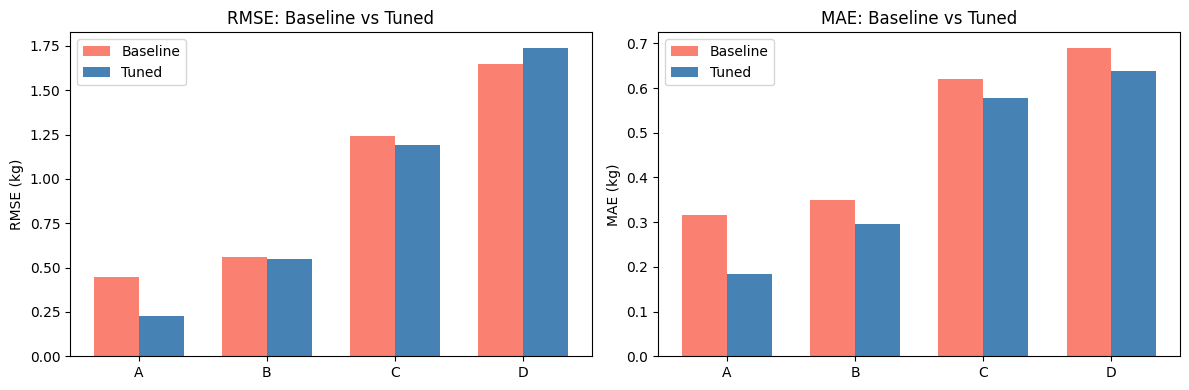

In [18]:
results_df = pd.DataFrame(results)
results_df["rmse_improvement_%"] = (
    (results_df["baseline_rmse"] - results_df["tuned_rmse"]) / results_df["baseline_rmse"] * 100
).round(2)
results_df["mae_improvement_%"] = (
    (results_df["baseline_mae"] - results_df["tuned_mae"]) / results_df["baseline_mae"] * 100
).round(2)

print("\n=== Model Performance Summary ===")
print(results_df.to_string(index=False))

# Bar chart comparison
x = np.arange(len(results_df))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - width/2, results_df["baseline_rmse"], width, label="Baseline", color="salmon")
axes[0].bar(x + width/2, results_df["tuned_rmse"],    width, label="Tuned",    color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df["section"])
axes[0].set_title("RMSE: Baseline vs Tuned")
axes[0].set_ylabel("RMSE (kg)")
axes[0].legend()

axes[1].bar(x - width/2, results_df["baseline_mae"], width, label="Baseline", color="salmon")
axes[1].bar(x + width/2, results_df["tuned_mae"],    width, label="Tuned",    color="steelblue")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df["section"])
axes[1].set_title("MAE: Baseline vs Tuned")
axes[1].set_ylabel("MAE (kg)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4b. Feature Importance (Tuned Models)

XGBoost provides built‑in feature importance scores. Here we plot the top 15 features for each section.

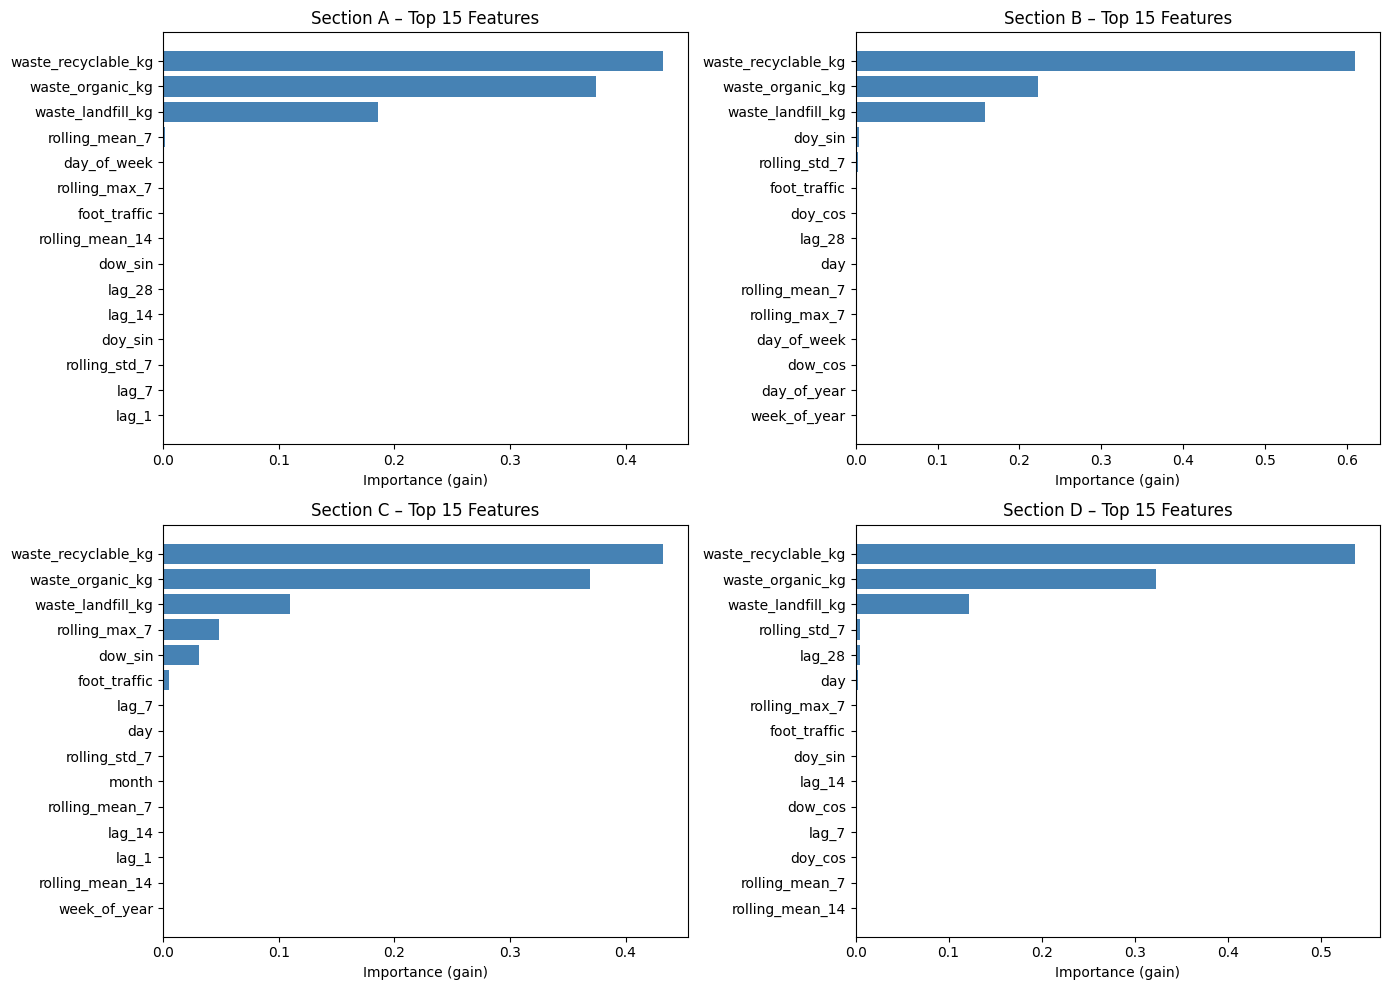

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, section in enumerate(sections):
    model_path = f"models/xgboost/xgboost_section_{section}.pkl"
    with open(model_path, "rb") as f:
        model = pickle.load(f)

    importance = pd.Series(
        model.feature_importances_,
        index=model.feature_names_in_
    ).sort_values(ascending=False).head(15)

    axes[i].barh(importance.index[::-1], importance.values[::-1], color="steelblue")
    axes[i].set_title(f"Section {section.upper()} – Top 15 Features")
    axes[i].set_xlabel("Importance (gain)")

plt.tight_layout()
plt.show()

## 5. Usage: Load a Saved Model and Forecast Future Waste

Here we demonstrate how to load one of the saved XGBoost models and generate a forecast for the next 14 days.

Because XGBoost is not a native time‑series model, we use a **recursive / multi‑step** strategy:
each predicted value is fed back as the `lag_1` feature for the next step, while `lag_7`, `lag_14`, `lag_28` and rolling features are updated accordingly.

Loaded model for section A

14‑step recursive forecast for Section A:
 step  forecast_kg
    1         8.06
    2         8.04
    3         8.04
    4         8.05
    5         8.05
    6         8.07
    7         8.08
    8         8.08
    9         8.07
   10         8.08
   11         8.08
   12         8.08
   13         8.07
   14         8.09


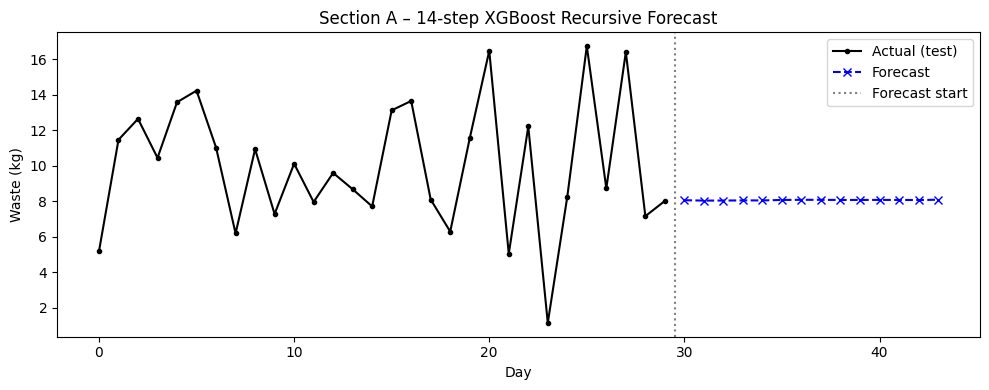

In [20]:
model_path = "models/xgboost/xgboost_section_a.pkl"
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

print("Loaded model for section A")

_, train_a, test_a = prepare_section_data(df, "a", test_rows=30)
history = pd.concat([train_a, test_a]).reset_index(drop=True)

forecast_horizon = 14
feature_cols = [c for c in history.columns if c != TARGET]

# Assumed future exogenous values (foot_traffic, is_holiday, has_special_event)
future_exog = {
    "foot_traffic":      55.0,
    "is_holiday":        0,
    "has_special_event": 0
}

predictions = []
current_history = history.copy()

for step in range(forecast_horizon):
    last_row = current_history.iloc[-1].copy()
    last_date_idx = len(current_history) - 1

    # Build next row features
    next_row = last_row.copy()

    # Update date‑based features (advance by 1 day)
    next_day_of_week = (int(last_row["day_of_week"]) + 1) % 7
    next_row["day_of_week"] = next_day_of_week
    next_row["is_weekend"]  = 1 if next_day_of_week in [5, 6] else 0
    next_row["dow_sin"] = np.sin(2 * np.pi * next_day_of_week / 7)
    next_row["dow_cos"] = np.cos(2 * np.pi * next_day_of_week / 7)

    # Update exogenous features
    for col, val in future_exog.items():
        next_row[col] = val

    # Update lag features using previous predictions
    next_row["lag_1"]  = current_history[TARGET].iloc[-1]
    next_row["lag_7"]  = current_history[TARGET].iloc[-7]  if len(current_history) >= 7  else np.nan
    next_row["lag_14"] = current_history[TARGET].iloc[-14] if len(current_history) >= 14 else np.nan
    next_row["lag_28"] = current_history[TARGET].iloc[-28] if len(current_history) >= 28 else np.nan

    # Update rolling features
    recent_7  = current_history[TARGET].iloc[-7:]
    recent_14 = current_history[TARGET].iloc[-14:]
    next_row["rolling_mean_7"]  = recent_7.mean()
    next_row["rolling_mean_14"] = recent_14.mean()
    next_row["rolling_std_7"]   = recent_7.std()
    next_row["rolling_max_7"]   = recent_7.max()

    # Predict
    X_next = next_row[feature_cols].values.reshape(1, -1)
    pred = loaded_model.predict(X_next)[0]
    predictions.append(pred)

    # Append predicted row to history for next iteration
    next_row[TARGET] = pred
    current_history = pd.concat(
        [current_history, next_row.to_frame().T], ignore_index=True
    )

forecast_df = pd.DataFrame({
    "step":        range(1, forecast_horizon + 1),
    "forecast_kg": np.round(predictions, 2)
})
print("\n14‑step recursive forecast for Section A:")
print(forecast_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(test_a)), test_a[TARGET].values,
        label="Actual (test)", color="black", marker="o", markersize=3)
ax.plot(
    range(len(test_a), len(test_a) + forecast_horizon),
    predictions,
    label="Forecast", color="blue", linestyle="--", marker="x"
)
ax.axvline(x=len(test_a) - 0.5, color="grey", linestyle=":", label="Forecast start")
ax.set_title("Section A – 14‑step XGBoost Recursive Forecast")
ax.set_xlabel("Day")
ax.set_ylabel("Waste (kg)")
ax.legend()
plt.tight_layout()
plt.show()